# Explanatory Analysis — Fair Price Finder
**Dataset:** `merged_raw_imputed.csv`  
**Tim:** CC26-PSU164

Notebook ini menjawab pertanyaan bisnis secara spesifik menggunakan visualisasi yang terstruktur.

---

## Pertanyaan Bisnis

1. **Berapa rentang harga wajar untuk tiap sub-kategori layanan freelance di Indonesia?**
2. **Apakah platform mempengaruhi harga secara signifikan untuk layanan yang sama?**
3. **Skill apa yang paling berpengaruh terhadap harga tinggi?**
4. **Apakah freelancer dengan rating & order lebih tinggi cenderung memasang harga lebih mahal?**
5. **Berapa durasi pengerjaan yang umum untuk tiap kategori, dan apakah berkorelasi dengan harga?**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def find_project_root():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / "data").exists():
            return candidate
    return current_dir


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data" / "cleaned" / "merged_raw_imputed.csv"

df = pd.read_csv(DATA_PATH)
# Data valid untuk analisis (pastikan harga ada)
df_valid = df[df['harga'].notna()].copy()
print(f'Shape: {df.shape}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Jumlah baris: {df.shape[0]}')

Shape: (5461, 10)
Jumlah kolom: 10
Jumlah baris: 5461


---
## Q1: Berapa rentang harga wajar untuk tiap sub-kategori?

**Metrik:** Q25, median, Q75 sebagai batas bawah, tengah, dan atas harga wajar.

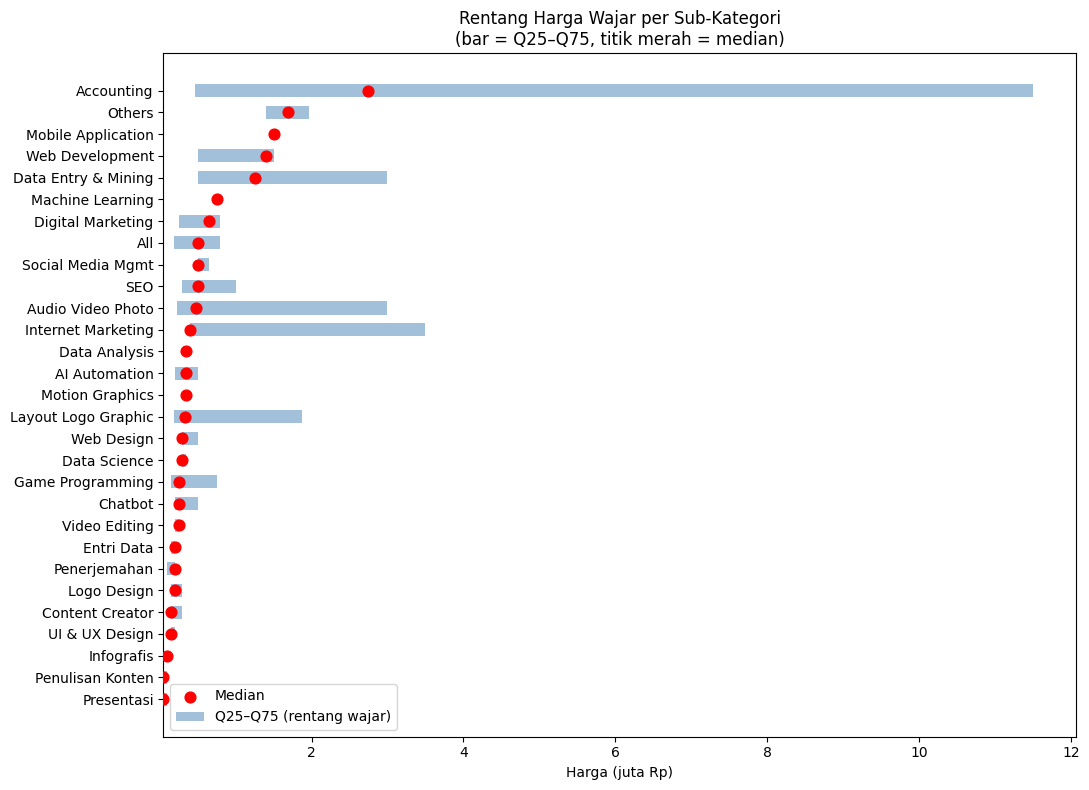


Tabel Rentang Harga Wajar:


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24048\2509289793.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  harga_range.applymap(lambda x: f'Rp {x:,.0f}')


,harga_min,harga_median,harga_max
sub_kategori,,,
Presentasi,"Rp 50,000","Rp 50,000","Rp 100,000"
Penulisan Konten,"Rp 50,000","Rp 50,000","Rp 100,000"
Infografis,"Rp 100,000","Rp 100,000","Rp 100,000"
UI & UX Design,"Rp 150,000","Rp 150,000","Rp 200,000"
Content Creator,"Rp 150,000","Rp 150,000","Rp 300,000"
Logo Design,"Rp 150,000","Rp 199,495","Rp 300,000"
Penerjemahan,"Rp 100,000","Rp 200,000","Rp 200,000"
Entri Data,"Rp 150,000","Rp 200,000","Rp 200,000"
Video Editing,"Rp 200,000","Rp 250,000","Rp 250,000"


In [2]:
harga_range = df_valid.groupby('sub_kategori')['harga'].agg(
    harga_min=lambda x: x.quantile(0.25),
    harga_median='median',
    harga_max=lambda x: x.quantile(0.75)
).sort_values('harga_median')

fig, ax = plt.subplots(figsize=(11, 8))

y = range(len(harga_range))
ax.barh(y, 
        (harga_range['harga_max'] - harga_range['harga_min']) / 1e6,
        left=harga_range['harga_min'] / 1e6,
        height=0.6, color='steelblue', alpha=0.5, label='Q25–Q75 (rentang wajar)')
ax.scatter(harga_range['harga_median'] / 1e6, y, 
           color='red', zorder=5, s=60, label='Median')

ax.set_yticks(y)
ax.set_yticklabels(harga_range.index)
ax.set_xlabel('Harga (juta Rp)')
ax.set_title('Rentang Harga Wajar per Sub-Kategori\n(bar = Q25–Q75, titik merah = median)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTabel Rentang Harga Wajar:')
harga_range.applymap(lambda x: f'Rp {x:,.0f}')

**Insight:** Sub-kategori dengan rentang paling lebar (Web Development, Mobile Application, Machine Learning) menunjukkan variasi kualitas/pengalaman freelancer yang tinggi — cocok untuk model prediksi karena ada ruang untuk diferensiasi harga.

---
## Q2: Apakah platform mempengaruhi harga untuk layanan yang sama?

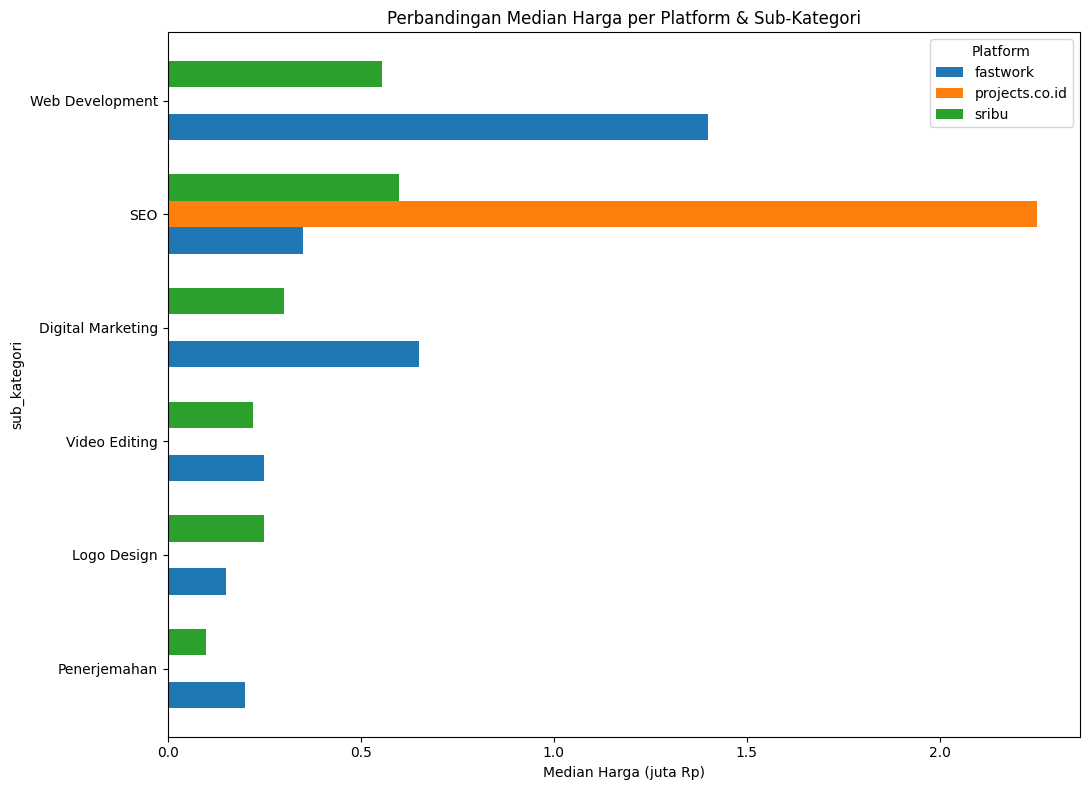


Rasio median harga platform vs Fastwork:
platform
fastwork          1.00
projects.co.id    2.67
sribu             0.83


In [3]:
# Fokus pada sub_kategori yang ada di semua platform
platform_subkat = df.groupby('sub_kategori')['platform'].nunique()
multi_platform = platform_subkat[platform_subkat >= 2].index
df_multi = df[df['sub_kategori'].isin(multi_platform)]

pivot = df_multi.groupby(['sub_kategori', 'platform'])['harga'].median().unstack()
pivot_sorted = pivot.median(axis=1).sort_values().index
pivot = pivot.loc[pivot_sorted]

fig, ax = plt.subplots(figsize=(11, 8))
pivot.div(1e6).plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('Median Harga (juta Rp)')
ax.set_title('Perbandingan Median Harga per Platform & Sub-Kategori')
ax.legend(title='Platform')
plt.tight_layout()
plt.show()

# Rasio harga relatif terhadap Fastwork
print('\nRasio median harga platform vs Fastwork:')
rasio = df.groupby('platform')['harga'].median()
print((rasio / rasio.get('fastwork', 1)).round(2).to_string())

**Insight:** projects.co.id secara konsisten memiliki harga lebih tinggi (~2–3x) dibanding Fastwork dan Sribu untuk kategori yang sama. Hal ini karena projects.co.id lebih banyak digunakan untuk proyek korporat dengan scope yang lebih besar. **Platform harus jadi fitur dalam model.**

---
## Q3: Skill apa yang paling berpengaruh terhadap harga tinggi?

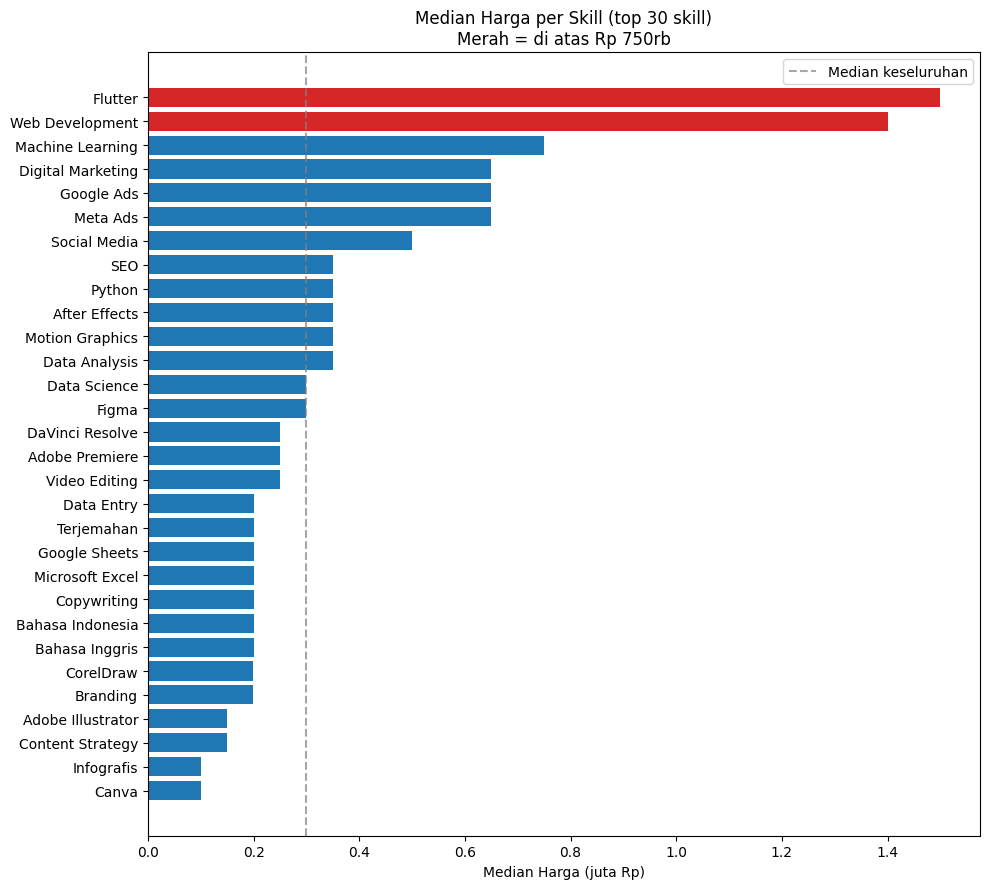


Top 10 skill dengan harga tertinggi:


,median_harga,jumlah
After Effects,"Rp 350,000",194.0
Python,"Rp 350,000",718.0
SEO,"Rp 350,000",591.0
Social Media,"Rp 500,000",350.0
Meta Ads,"Rp 650,000",310.0
Google Ads,"Rp 650,000",344.0
Digital Marketing,"Rp 650,000",292.0
Machine Learning,"Rp 750,000",350.0
Web Development,"Rp 1,400,000",298.0
Flutter,"Rp 1,500,000",181.0


In [4]:
from collections import Counter

all_skills = []
for s in df['skills'].dropna():
    all_skills.extend([x.strip() for x in str(s).split(',')])

top30_skills = [s for s, _ in Counter(all_skills).most_common(30)]

skill_stats = {}
for skill in top30_skills:
    mask = df['skills'].str.contains(skill, na=False, regex=False)
    skill_stats[skill] = {
        'median_harga': df.loc[mask, 'harga'].median(),
        'jumlah': mask.sum()
    }

skill_df = pd.DataFrame(skill_stats).T.sort_values('median_harga')

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#d62728' if v > 750_000 else '#1f77b4' for v in skill_df['median_harga']]
bars = ax.barh(skill_df.index, skill_df['median_harga'] / 1e6, color=colors)
ax.set_xlabel('Median Harga (juta Rp)')
ax.set_title('Median Harga per Skill (top 30 skill)\nMerah = di atas Rp 750rb')
ax.axvline(x=df['harga'].median()/1e6, color='gray', linestyle='--', alpha=0.7, label='Median keseluruhan')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 skill dengan harga tertinggi:')
skill_df.tail(10)[['median_harga','jumlah']].assign(
    median_harga=lambda x: x['median_harga'].apply(lambda v: f'Rp {v:,.0f}')
)

**Insight:** Skill teknis tinggi (Machine Learning, TensorFlow, Kotlin, Swift, SQL) berkorelasi dengan harga di atas rata-rata. Skill desain dan konten cenderung di bawah median. **Skills adalah fitur prediktif yang relevan untuk model.**

---
## Q4: Apakah rating & order lebih tinggi → harga lebih mahal?

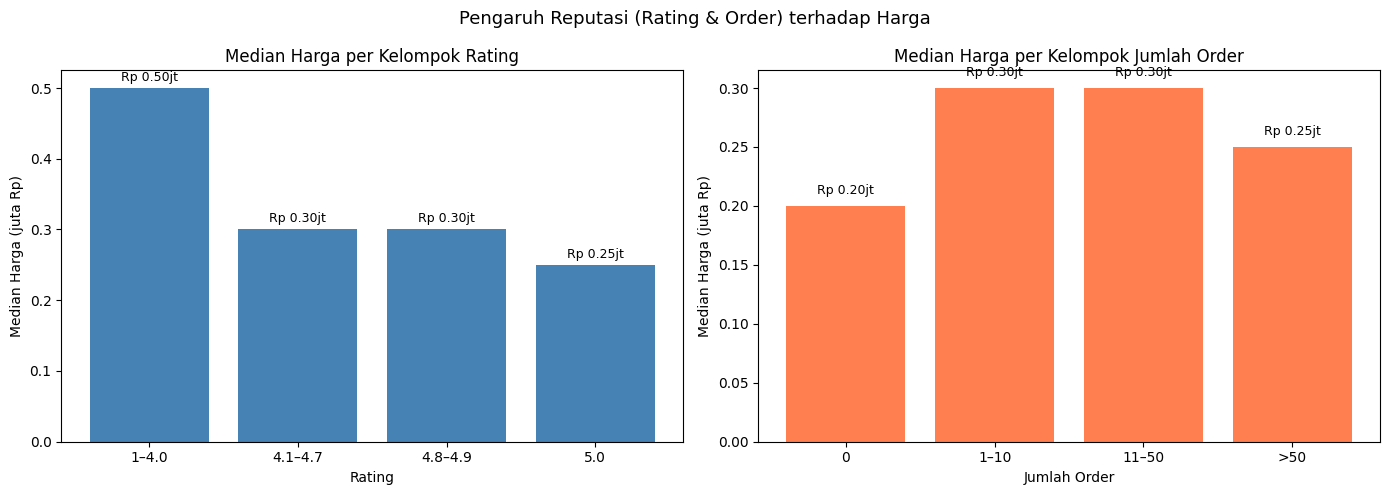

In [5]:
df_active = df[df['rating'] > 0].copy()

# Buat segmen rating
df_active['rating_group'] = pd.cut(
    df_active['rating'],
    bins=[0, 4.0, 4.7, 4.9, 5.0],
    labels=['1–4.0', '4.1–4.7', '4.8–4.9', '5.0']
)

# Buat segmen order
df_active['order_group'] = pd.cut(
    df_active['jumlah_order'],
    bins=[-1, 0, 10, 50, df_active['jumlah_order'].max()],
    labels=['0', '1–10', '11–50', '>50']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating vs harga
rating_harga = df_active.groupby('rating_group', observed=True)['harga'].median() / 1e6
axes[0].bar(rating_harga.index, rating_harga.values, color='steelblue')
axes[0].set_title('Median Harga per Kelompok Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Median Harga (juta Rp)')
for i, v in enumerate(rating_harga.values):
    axes[0].text(i, v + 0.01, f'Rp {v:.2f}jt', ha='center', fontsize=9)

# Order vs harga
order_harga = df_active.groupby('order_group', observed=True)['harga'].median() / 1e6
axes[1].bar(order_harga.index, order_harga.values, color='coral')
axes[1].set_title('Median Harga per Kelompok Jumlah Order')
axes[1].set_xlabel('Jumlah Order')
axes[1].set_ylabel('Median Harga (juta Rp)')
for i, v in enumerate(order_harga.values):
    axes[1].text(i, v + 0.01, f'Rp {v:.2f}jt', ha='center', fontsize=9)

plt.suptitle('Pengaruh Reputasi (Rating & Order) terhadap Harga', fontsize=13)
plt.tight_layout()
plt.show()

**Insight:** Freelancer dengan lebih banyak order (>50) cenderung memasang harga lebih tinggi, menunjukkan bahwa pengalaman dan track record mempengaruhi pricing. Namun rating saja tidak selalu linear dengan harga — banyak seller baru (rating 5.0 dari sedikit ulasan) yang harganya masih rendah.

---
## Q5: Berapa durasi umum per kategori, dan apakah berkorelasi dengan harga?

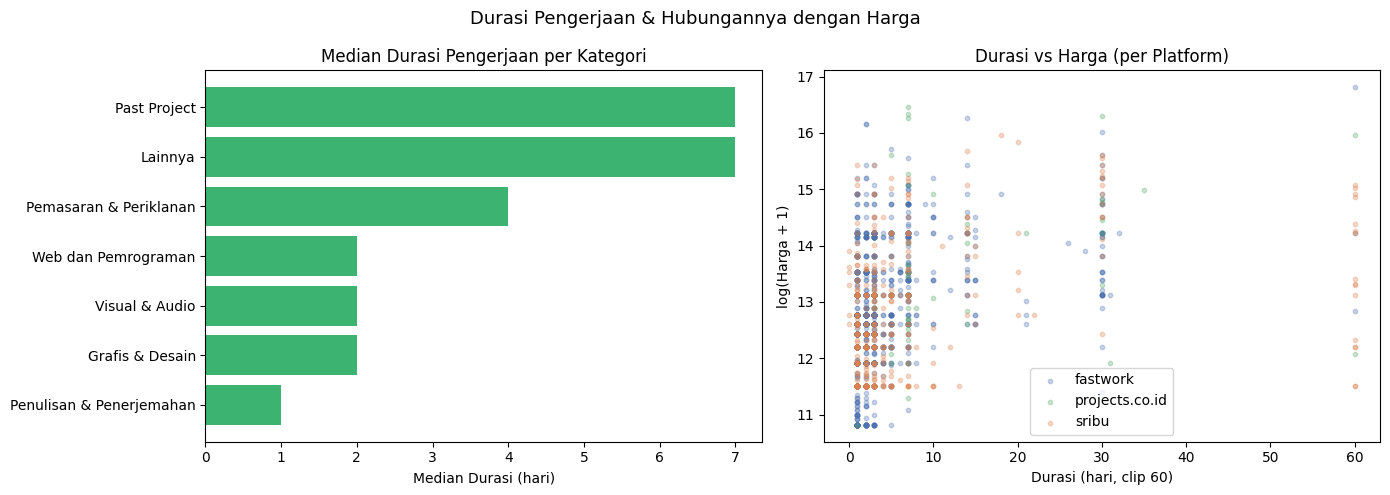

Korelasi Pearson durasi vs harga: 0.301


In [6]:
# Clip durasi ekstrem
df_dur = df_valid.copy()
df_dur['durasi_clip'] = df_dur['durasi_hari'].clip(upper=60)

# Median durasi per kategori utama
durasi_kat = df_dur.groupby('kategori_utama')['durasi_clip'].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(durasi_kat.index, durasi_kat.values, color='mediumseagreen')
axes[0].set_xlabel('Median Durasi (hari)')
axes[0].set_title('Median Durasi Pengerjaan per Kategori')

# Scatter durasi vs harga
sample = df_dur.sample(min(2000, len(df_dur)), random_state=42)
colors_map = {'fastwork': '#4C72B0', 'sribu': '#DD8452', 'projects.co.id': '#55A868'}
for platform, grp in sample.groupby('platform'):
    axes[1].scatter(
        grp['durasi_clip'], np.log1p(grp['harga']),
        alpha=0.3, s=10,
        color=colors_map.get(platform, 'gray'),
        label=platform
    )
axes[1].set_xlabel('Durasi (hari, clip 60)')
axes[1].set_ylabel('log(Harga + 1)')
axes[1].set_title('Durasi vs Harga (per Platform)')
axes[1].legend()

plt.suptitle('Durasi Pengerjaan & Hubungannya dengan Harga', fontsize=13)
plt.tight_layout()
plt.show()

corr = df_dur[['durasi_clip','harga']].corr().iloc[0,1]
print(f'Korelasi Pearson durasi vs harga: {corr:.3f}')

**Insight:** Durasi berkorelasi positif lemah dengan harga. Pekerjaan teknis seperti AI/ML dan Web Development cenderung memiliki durasi lebih panjang sekaligus harga lebih tinggi. Durasi tetap relevan sebagai fitur input model karena pengguna bisa memasukkan estimasi durasi saat minta prediksi harga.

---
## Kesimpulan Bisnis

| # | Pertanyaan | Kesimpulan |
|---|---|---|
| 1 | Rentang harga wajar? | Sangat bervariasi per sub-kategori: Rp 50rb (Penulisan Konten) – Rp 2.75jt (Accounting) median |
| 2 | Platform mempengaruhi harga? | **Ya**, projects.co.id 2–3x lebih mahal dari Fastwork/Sribu untuk layanan sama |
| 3 | Skill paling mahal? | Machine Learning, TensorFlow, Kotlin, Swift → harga di atas median |
| 4 | Rating/order → harga? | Order count lebih berpengaruh dari rating. Freelancer >50 order cenderung pasang harga lebih tinggi |
| 5 | Durasi vs harga? | Korelasi positif lemah — durasi tetap relevan sebagai fitur input |

**Implikasi untuk model:** Fitur terpenting adalah `sub_kategori`, `platform`, `skills`, dan `jumlah_order`. Target variable `harga` perlu di-log-transform sebelum training.